# Graph Convolutional Network (GCN) development for filtered drag force modeling

In [ ]:
# !pip install torch_geometric

### Data Loading and Preprocessing

In [ ]:
# import necessary libraries for data preprocessing and visualization
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy as sp
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Calculate terminal velocity iteratively from source code provided by (Hardy et.al, 2024) 
# Parameters for 275 micron particle 
g = 9.81            # m/s²
rho_g = 1.225       # kg/m³
rho_p = 2500        # kg/m³
mu_g = 1.8e-5       # Pa·s
dp = 275e-6         # m

def get_terminal_velocity(rho_p, rho_g, g, dp, mu_g):   
 # rho_p: density of the solid, 
 # rho_g: density of the fluid,
 # g: acceleration due to gravity,
 # dp: solid diameter
 # mu: dynamic viscosity of the fluid (gas)

 tol=1e-8
 delta= 2*tol
 count = 0
 max_count = 200
 CD=1 # drag coefficient (initialize with 1)...assumption

 while delta>tol and count<max_count:
    # calculate terminal velocity
    Ut = math.sqrt((4*dp*g*(rho_p - rho_g))/(3*CD*rho_g))
    # Reynolds number
    Ret = (rho_g*Ut*dp)/mu_g 
    
    if Ret < 1000:
        # Schiller-Naumann equation
        CD_new = (24/Ret)*(1 + 0.15*Ret**0.687) 
    else:
        CD_new = 0.44

    delta = abs(CD - CD_new)
    CD = CD_new
    count += 1
 print("Iterative process has converged in {:d} iterations".format(count))
 return Ut
Ut = get_terminal_velocity(rho_p, rho_g, g, dp, mu_g)
# Now using Ut calculate particle reynolds number and Froude number
Re_p = (rho_g * Ut * dp) / mu_g
Fr = Ut**2/(g*dp)
# Let's calculate characteristic length scale L_c
Lc = dp*Fr**(1/3)

#  similarly we calculate the terminal velocity, particle Reynolds number, Froude number and characteristic length scale for case 75 and case 300.
#  Case75
# 1. Terminal Velocity is:  0.3480815707017538
# 2. Particle Reynolds number is:  1.776666350456868
# 3. Froude number is:  164.67656114468232
# 4. Characteristic length scale L_c is:  0.000411091527800743\n
#  Case300
# 1. Terminal Velocity is:  2.2232632008524815
# 2. Particle Reynolds number is:  45.3916236840715
# 3. Froude number is:  1679.544430942855
# 4. Characteristic length scale L_c is:  0.0035660307774051875

### Upload filtered data files of all cases

In [ ]:
# Filtered files: created by applying spatial filter to fluidizing region (see recreate_2d_grid_from_cfd_data_snapshot.ipynb in repo)
import glob
# Base path containing all folders
base_path = "./GNN_data" # use your own path here
# Separate folder groups
folders_275 = [
    "filtered_files_dense_275","filtered_files_moderate_dense_275",
    "filtered_files_dilute_275","filtered_files_highly_dilute_275", "filtered_files_added_275"
]

folders_300 = [
    "filtered_files_dense_300","filtered_files_moderate_dense_300",
    "filtered_files_dilute_300","filtered_files_highly_dilute_300","filtered_files_added_300"
]

folder_75=["filtered_files_dense_75","filtered_files_moderate_dense_75",
          "filtered_files_dilute_75","filtered_files_highly_dilute_75"]

# just use the required columns (features and target label)
required_cols = [ "gas-vof", "solid-vof", "alp_vd", "Re_p", "Fr", "u_slip_y", "Delta_f", "tau_p_tilde", "dpdy_filtered", "fd_y",'vd_y']

# Load 275 group 
data_275 = []

for folder in folders_275:
    print(f"\nProcessing folder: {folder}")
    folder_path = os.path.join(base_path, folder)
    files = glob.glob(os.path.join(folder_path, "*.xlsx"))
    
    for file in files:
        # Skip temporary Excel files
        if os.path.basename(file).startswith("~$"):
            continue
        
        print(f"  Loading file: {os.path.basename(file)}")  
        df = pd.read_excel(file, usecols=required_cols)
        
        sample = {
            "data": df,
            "folder": folder,
            "filename": os.path.basename(file)
        }
        data_275.append(sample)

print("\nFinished loading 275 group:", len(data_275), "files")
# Load 300 group 
data_300 = []

for folder in folders_300:
    print(f"\nProcessing folder: {folder}")
    folder_path = os.path.join(base_path, folder)
    files = glob.glob(os.path.join(folder_path, "*.xlsx"))
    
    for file in files:
        if os.path.basename(file).startswith("~$"):
            continue
        
        print(f"  Loading file: {os.path.basename(file)}")
        df = pd.read_excel(file, usecols=required_cols)
        
        sample = {
            "data": df,
            "folder": folder,
            "filename": os.path.basename(file)
        }
        data_300.append(sample)

print("\nFinished loading 300 group:", len(data_300), "files")
# Load 75 group
data_75 = []

for folder in folder_75:
    print(f"\nProcessing folder: {folder}")
    folder_path = os.path.join(base_path, folder)
    files = glob.glob(os.path.join(folder_path, "*.xlsx"))
    
    for file in files:
        if os.path.basename(file).startswith("~$"):
            continue
        
        print(f"  Loading file: {os.path.basename(file)}")
        df = pd.read_excel(file, usecols=required_cols)
        
        sample = {
            "data": df,
            "folder": folder,
            "filename": os.path.basename(file)
        }
        data_75.append(sample)
        
print("\nFinished loading 75 group:", len(data_75), "files")




Processing folder: filtered_files_dense_275
  Loading file: filter_size_10_t1.xlsx
  Loading file: filter_size_10_t2.xlsx
  Loading file: filter_size_10_t3.xlsx
  Loading file: filter_size_12_t1.xlsx
  Loading file: filter_size_12_t2.xlsx
  Loading file: filter_size_12_t3.xlsx
  Loading file: filter_size_16_t1.xlsx
  Loading file: filter_size_16_t2.xlsx
  Loading file: filter_size_16_t3.xlsx
  Loading file: filter_size_2_t1.xlsx
  Loading file: filter_size_2_t2.xlsx
  Loading file: filter_size_2_t3.xlsx
  Loading file: filter_size_6_t1.xlsx
  Loading file: filter_size_6_t2.xlsx
  Loading file: filter_size_6_t3.xlsx
  Loading file: filter_size_8_t1.xlsx
  Loading file: filter_size_8_t2.xlsx
  Loading file: filter_size_8_t3.xlsx

Processing folder: filtered_files_moderate_dense_275
  Loading file: filter_size_10_t1.xlsx
  Loading file: filter_size_10_t2.xlsx
  Loading file: filter_size_10_t3.xlsx
  Loading file: filter_size_12_t1.xlsx
  Loading file: filter_size_12_t2.xlsx
  Loading fil

### Saved all filtered data as pickle files for easy loading in the future

In [ ]:
# import pickle
# with open("./GNN_data/saved_data_pickles/unscaled_data_275.pkl", "wb") as f:
#     pickle.dump(data_275, f)
# with open("./GNN_data/saved_data_pickles/unscaled_data_300.pkl", "wb") as f:
#     pickle.dump(data_300, f)
# with open("./GNN_data/saved_data_pickles/unscaled_data_75.pkl", "wb") as f:
#     pickle.dump(data_75, f)

### Scale Data for generalization


In [ ]:
import os
import pickle

alp_max = 0.63
rho_s   = 2500
g       = 9.81

# Group-specific constants
scaling_params = {
    "275": {"Ut": 2.026610816690855, "Lc": 0.00316358152730544},
    "300": {"Ut": 2.2232632008524815, "Lc": 0.0035660307774051875},
    "75":  {"Ut": 0.3480815707017538, "Lc": 0.000411091527800743},
}

# Paths 
raw_pickle_dir    = "./GNN_data/saved_data_pickles" # use your own path here
scaled_pickle_dir = "./GNN_data/scaled_data" # use your own path here
os.makedirs(scaled_pickle_dir, exist_ok=True)

group_files = {
    "275": "unscaled_data_275.pkl",
    "300": "unscaled_data_300.pkl",
    "75":  "unscaled_data_75.pkl"
}


for group, filename in group_files.items():
    # Load raw data
    with open(os.path.join(raw_pickle_dir, filename), "rb") as f:
        data_group = pickle.load(f)

    print(f"\nProcessing group {group}, {len(data_group)} files")

    Ut = scaling_params[group]["Ut"]
    Lc = scaling_params[group]["Lc"]

    
    for sample in data_group:
        df = sample["data"].copy()  # copy to avoid modifying original accidentally

        # Fill missing values with column mean
        df.fillna(df.mean(), inplace=True)

        # Scaling 
        df["solid-vof"]     = df["solid-vof"] / alp_max
        df["alp_vd"]        = df["alp_vd"] / (Ut * alp_max)
        df["u_slip_y"]      = df["u_slip_y"] / Ut
        df["Delta_f"]       = df["Delta_f"] / Lc
        df["dpdy_filtered"] = df["dpdy_filtered"] / (rho_s * g)
        df["fd_y"]          = df["fd_y"] / (rho_s * g)

        # Update sample
        sample["data"] = df
        sample["scaled"] = True
        sample["meta"] = {"Ut": Ut, "Lc": Lc, "alp_max": alp_max}

    # --- Save scaled pickle ---
    scaled_filename = f"scaled_data_{group}_dict.pkl"
    with open(os.path.join(scaled_pickle_dir, scaled_filename), "wb") as f:
        pickle.dump(data_group, f)

    print(f"Saved scaled data for group {group} as {scaled_filename}")



Processing group 275, 90 files
Saved scaled data for group 275 as scaled_data_275_dict.pkl

Processing group 300, 90 files
Saved scaled data for group 300 as scaled_data_300_dict.pkl

Processing group 75, 72 files
Saved scaled data for group 75 as scaled_data_75_dict.pkl


### GCN

In [ ]:
# import libraries for GCN model
import pickle
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Load the scaled data Pickle files and create PyTorch Geometric datasets

In [ ]:
# use your own path here
with open("./GNN_data/scaled_data/scaled_data_275_dict.pkl", "rb") as f: 
    scaled_data_275 = pickle.load(f)
with open("./GNN_data/scaled_data/scaled_data_300_dict.pkl", "rb") as f:
    scaled_data_300 = pickle.load(f)
with open("./GNN_data/scaled_data/scaled_data_75_dict.pkl", "rb") as f: 
    scaled_data_75 = pickle.load(f)

In [4]:
data = scaled_data_275 + scaled_data_300 + scaled_data_75
ny, nx = 450, 224
N= ny* nx
print("Total graph samples:", len(data))

feature_cols = ['solid-vof', 'u_slip_y','dpdy_filtered']
label_cols   = ['alp_vd']

Total graph samples: 252


In [ ]:
# Graph construction
graphs = []
for sample in data:
    df = sample["data"]
    X = df[feature_cols].values.reshape(ny,nx,-1)
    y = df[label_cols].values.reshape(ny,nx,-1)
    graphs.append({
        "case": sample["folder"],
        "filename": sample["filename"],
        "X_grid": X,
        "y_grid": y
    })

for g in graphs:
    X_flat = g["X_grid"].reshape(-1, g["X_grid"].shape[2]) # 100800 x 5 
    y_flat = g["y_grid"].reshape(-1, 1) # 100800 x 1
    g["X_flat"] = X_flat 
    g["y_flat"] = y_flat

# edge indexing

def build_undirected_grid_edges(ny, nx):
    edges = []

    for i in range(ny):
        for j in range(nx):
            node_id = i * nx + j

            forward_neighbors = [
                (i, j+1),     # right
                (i+1, j),     # down
                (i+1, j+1),   # down-right
                (i+1, j-1)    # down-left
            ]

            for ni, nj in forward_neighbors:
                if 0 <= ni < ny and 0 <= nj < nx:
                    neighbor_id = ni * nx + nj
                    edges.append([node_id, neighbor_id])

    # Mirror edges to make undirected
    edge_list = edges.copy()
    for a, b in edges:
        edge_list.append([b, a])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    return edge_index

# Example usage
ny, nx = 450, 224
edge_index = build_undirected_grid_edges(ny, nx)
# print("Edge index shape:", edge_index.shape)  


### GCN Architecture

In [18]:
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv

class GCNRegressor(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 128)  
        self.conv2 = GCNConv(128, 64)          
        self.conv3 = GCNConv(64, 8)             
        self.lin   = nn.Linear(8, 1)            

    def forward(self, x, edge_index):
        h = torch.relu(self.conv1(x, edge_index))
        h = torch.relu(self.conv2(h, edge_index))
        h = torch.relu(self.conv3(h, edge_index))
        out = self.lin(h)
        return h, out
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=GCNRegressor(in_channels=len(feature_cols)).to(device)
print(model)

GCNRegressor(
  (conv1): GCNConv(3, 128)
  (conv2): GCNConv(128, 64)
  (conv3): GCNConv(64, 8)
  (lin): Linear(in_features=8, out_features=1, bias=True)
)


In [ ]:
# Prepare PyG Data objects
train_data_objects = [
    Data(
        x=torch.tensor(g["X_flat"], dtype=torch.float),
        y=torch.tensor(g["y_flat"], dtype=torch.float),
        edge_index=edge_index,
        num_nodes=g["X_flat"].shape[0]
    ) for g in train_graphs
]
test_data_objects = [
    Data(
        x=torch.tensor(g["X_flat"], dtype=torch.float),
        y=torch.tensor(g["y_flat"], dtype=torch.float),
        edge_index=edge_index,
        num_nodes=g["X_flat"].shape[0]
    ) for g in test_graphs
]

### k-fold cross validation training loop

In [ ]:
# K-Fold Cross Validation
k = 8
num_epochs = 300
patience = 20

kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_results = []

# Track per-fold metrics for visualization
train_losses_per_fold = []
val_losses_per_fold = []
val_r2_per_fold = []

for fold, (train_idx, val_idx) in enumerate(kf.split(train_data_objects)):
    print(f"\n===== Fold {fold+1}/{k} =====")
    
    train_subset = [train_data_objects[i] for i in train_idx]
    val_subset   = [train_data_objects[i] for i in val_idx]
    
    train_loader = DataLoader(train_subset, batch_size=1, shuffle=True)
    val_loader   = DataLoader(val_subset, batch_size=1, shuffle=False)
    
    model=GCNRegressor(in_channels=len(feature_cols)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    
    best_val_loss = np.inf
    best_embeddings = None
    counter = 0

    # Track losses per epoch
    train_losses = []
    val_losses = []
    val_r2s = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            h, pred = model(batch.x, batch.edge_index)
            loss = loss_fn(pred, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        val_y_true, val_y_pred = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                h, pred = model(batch.x, batch.edge_index)
                val_loss += loss_fn(pred, batch.y).item()
                val_y_true.append(batch.y.cpu().numpy())
                val_y_pred.append(pred.cpu().numpy())
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        val_y_true = np.vstack(val_y_true)
        val_y_pred = np.vstack(val_y_pred)
        r2 = r2_score(val_y_true, val_y_pred)
        val_r2s.append(r2)

        # Save best embeddings
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_embeddings = h.cpu().detach()
            counter = 0
            torch.save({
                "model_state": model.state_dict(),
                "embeddings": best_embeddings
            }, f"best_3_marker_df_model_fold{fold}_updated.pt")
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered")
                break

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train MSE={avg_train_loss:.6f}, Val MSE={avg_val_loss:.6f}, R2={r2:.4f}")

    fold_results.append(best_val_loss)
    train_losses_per_fold.append(train_losses)
    val_losses_per_fold.append(val_losses)
    val_r2_per_fold.append(val_r2s)


===== Fold 1/8 =====
Epoch 0: Train MSE=0.015714, Val MSE=0.008474, R2=0.3554
Epoch 10: Train MSE=0.004542, Val MSE=0.003142, R2=0.7610
Epoch 20: Train MSE=0.002655, Val MSE=0.002101, R2=0.8402
Epoch 30: Train MSE=0.001816, Val MSE=0.001738, R2=0.8678
Epoch 40: Train MSE=0.001529, Val MSE=0.002178, R2=0.8343
Epoch 50: Train MSE=0.001345, Val MSE=0.001312, R2=0.9002
Epoch 60: Train MSE=0.001328, Val MSE=0.001395, R2=0.8939
Epoch 70: Train MSE=0.001193, Val MSE=0.001318, R2=0.8997
Epoch 80: Train MSE=0.001642, Val MSE=0.002907, R2=0.7789
Epoch 90: Train MSE=0.001131, Val MSE=0.001172, R2=0.9108
Epoch 100: Train MSE=0.001206, Val MSE=0.001561, R2=0.8812
Epoch 110: Train MSE=0.001155, Val MSE=0.001335, R2=0.8984
Epoch 120: Train MSE=0.001417, Val MSE=0.001228, R2=0.9066
Epoch 130: Train MSE=0.001070, Val MSE=0.001094, R2=0.9168
Epoch 140: Train MSE=0.001286, Val MSE=0.001465, R2=0.8886
Epoch 150: Train MSE=0.001159, Val MSE=0.001109, R2=0.9157
Epoch 160: Train MSE=0.001316, Val MSE=0.0010

In [ ]:
# best fold = best model
best_fold_idx = np.argmin(fold_results)
print("Best fold for testing:", best_fold_idx)

checkpoint = torch.load(f"best_3_marker_df_model_fold{best_fold_idx}_updated.pt")
model.load_state_dict(checkpoint["model_state"])
model.eval()

Best fold for testing: 3


GCNRegressor(
  (conv1): GCNConv(3, 128)
  (conv2): GCNConv(128, 64)
  (conv3): GCNConv(64, 8)
  (lin): Linear(in_features=8, out_features=1, bias=True)
)

In [ ]:
# this step is performed after training all folds and selecting the best fold, so we save the final model state and training history for later use and visualization
# here we have saved the weights and biases, feature columns, and best fold index for later use
torch.save({
    "model_state": model.state_dict(),
    "feature_cols": feature_cols,
    "best_fold": best_fold_idx
}, "final_3_marker_gcn_DF_model_updated.pt")

# here we have saved the losses during training for later plotting
torch.save({
    "train_losses_per_fold": train_losses_per_fold,
    "val_losses_per_fold": val_losses_per_fold,
    "val_r2_per_fold": val_r2_per_fold
}, "training_history_3_marker_DF_model_updated.pt")



### Reload the saved model without retraining the model

In [ ]:
# Load the saved best model for inference/testing.
# No retraining required—skip the k-fold cross validation training cell and
# run the notebook starting after the GCN markdown section without k-fold training loop.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GCNRegressor(in_channels=3).to(device)
checkpoint = torch.load("final_3_marker_gcn_DF_model_updated.pt",
    map_location=device,
    weights_only=False)
model.load_state_dict(checkpoint["model_state"])
model.eval()

# Similarly, to plot losses later, we load the training history (without retraining), which contains the train and validation losses and R2 scores for each fold across epochs  
# history = torch.load(
#     "training_history_3_marker_DF_model_updated.pt",
#     weights_only=False  
# )
# train_losses_per_fold = history["train_losses_per_fold"]
# val_losses_per_fold   = history["val_losses_per_fold"]
# val_r2_per_fold       = history["val_r2_per_fold"]


### Apply best fold model on test graph set and visualize predictions vs true values

In [ ]:
from torch_geometric.loader import DataLoader  

test_data_objects = [
    Data(
        x=torch.tensor(g["X_flat"], dtype=torch.float),
        y=torch.tensor(g["y_flat"], dtype=torch.float),
        edge_index=edge_index,
        num_nodes=g["X_flat"].shape[0]
    ) for g in test_graphs
]

test_loader = DataLoader(test_data_objects, batch_size=1, shuffle=False)

test_y_true, test_y_pred = [], []
test_embeddings = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        h, pred = model(batch.x, batch.edge_index)
        test_embeddings.append(h.cpu())
        test_y_true.append(batch.y.cpu().numpy())
        test_y_pred.append(pred.cpu().numpy())

test_y_true = np.vstack(test_y_true)
test_y_pred = np.vstack(test_y_pred)

mse = mean_squared_error(test_y_true, test_y_pred)
mae = mean_absolute_error(test_y_true, test_y_pred)
r2 = r2_score(test_y_true, test_y_pred)



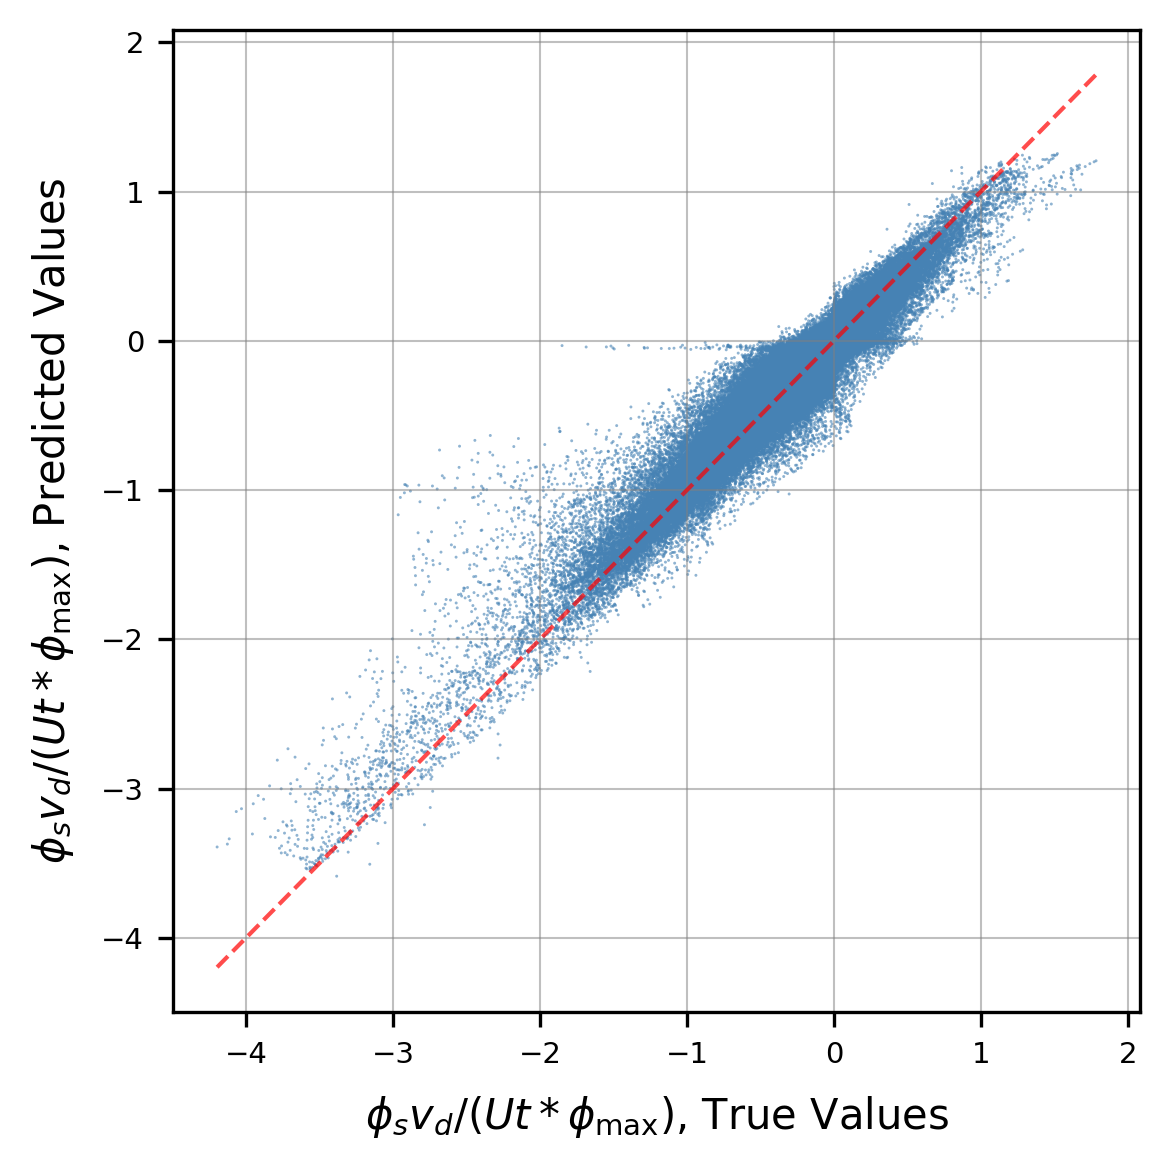

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

y_true = test_y_true.flatten()
y_pred = test_y_pred.flatten()

plt.figure(figsize=(4, 4), dpi=300, facecolor='white')
plt.scatter(y_true, y_pred, 
            s=0.5,
            alpha=0.6, 
            c='steelblue',
            edgecolors='none')

plt.plot([y_true.min(), y_true.max()], 
         [y_true.min(), y_true.max()], 
         'r--', 
         lw=1,
         alpha=0.7)

plt.xlabel(r"$\phi_s v_d / (Ut* \phi_{\mathrm{max}})$, True Values", 
           fontsize=10, labelpad=6)
plt.ylabel(r"$\phi_s v_d / (Ut* \phi_{\mathrm{max}})$, Predicted Values", 
           fontsize=10, labelpad=6)

plt.grid(True, linestyle='-', color='gray', alpha=0.5, linewidth=0.5)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
r2 = r2_score(y_true, y_pred)
plt.tight_layout()
plt.show()

### Filter Drag force calculation based on drift flux model

In [ ]:
graphs_test = []

for sample in data:
    if "t3" in sample["filename"]:   
        df = sample["data"]
        
        # Print the 'alp_vd' column
        # print(df['fd_y'])
        
        X = df[feature_cols].values.reshape(ny, nx, -1)
        y = df[label_cols].values.reshape(ny, nx, -1)
        X_flat = X.reshape(-1, X.shape[2])
        y_flat = y.reshape(-1, 1)

        graphs_test.append({
            "X_flat": X_flat,
            "y_flat": y_flat,
            "df": df,              
            "filename": sample["filename"]
        })
fd_true = []

for g in graphs_test:  # graphs_test "t3" files
    fd_true.append(g['df']['fd_y'].values)  
# Combine all arrays into one
fd_true = np.hstack(fd_true)

alp_max = 0.63
g = 9.81

# Flatten quantities for all graphs into 1D arrays
Ut_all      = np.hstack([g["df"]["ut"].values for g in graphs_test])
alp_all     = np.hstack([g["df"]["solid-vof"].values for g in graphs_test]) * alp_max
u_slip_all  = np.hstack([g["df"]["u_slip_y"].values for g in graphs_test]) * Ut_all
tau_p_all   = np.hstack([g["df"]["tau_p_tilde"].values for g in graphs_test])

alp_vd_physical_all = test_y_pred.flatten() * Ut_all*alp_max

# Compute drag force elementwise
fd_model_all_true = (alp_all * u_slip_all + alp_vd_physical_all) / (tau_p_all * g)

fd_true = np.round(fd_true, 2)
fd_model_all_true = np.round(fd_model_all_true, 2)
r2_fd = r2_score(fd_true, fd_model_all_true)
# print(f"R² between fd_model_all_true and fd_true: {r2_fd:.2f}")